In [20]:
from langgraph.graph import StateGraph, START
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool

from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.tools import YouTubeSearchTool
from langchain_experimental.tools import PythonREPLTool
from langchain_community.tools import HumanInputRun

import requests
from datetime import datetime

In [21]:
llm = ChatOllama(model="qwen2.5:1.5b", temperature=0)

In [22]:
search_tool = DuckDuckGoSearchRun(region="bd-en")
youtube_tool = YouTubeSearchTool()
python_execution_tool = PythonREPLTool()
human_tool = HumanInputRun()

In [23]:

@tool
def calculate_age(birth_date_str: str) -> dict:
    """
    Calculates age given a birth date string formatted as 'YYYY-MM-DD'.
    Example input: '2000-05-12'.
    Example output: You are 26 years 4 months 5 days old
    """
    try:
        birth_date = datetime.strptime(birth_date_str, "%Y-%m-%d").date()
        today = datetime.today().date()
        
        if birth_date > today:
            return {"error": "Birth date cannot be in the future."}
            
        days=today.year*365+today.month*30+today.day - (birth_date.year*365+birth_date.month*30+birth_date.day)
        age_years = int(days/365)
        age_months = int((days-(age_years*365))/30)
        age_days = int(days-(age_years*365+age_months*30))
        
        return {
            "birth_date": birth_date_str,
            "age_years": age_years,
            "age_months": age_months,
            "age_days": age_days
            }       
                
    except ValueError:
        return {"error": "Invalid date format. Please use 'YYYY-MM-DD'."}
    except Exception as e:
        return {"error": str(e)}



In [24]:

@tool
def get_current_weather(city: str) -> dict:
    """
    Fetches real-time weather details for a given city name using Open-Meteo.
    Example input: 'Sylhet' or 'Dhaka'
    """
    try:
        # Step 1: Geocoding to get latitude & longitude
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1"
        geo_res = requests.get(geo_url, timeout=10)
        geo_res.raise_for_status()
        geo_data = geo_res.json()
        
        if not geo_data.get("results"):
            return {"error": f"City '{city}' not found."}
            
        location = geo_data["results"][0]
        lat, lon = location["latitude"], location["longitude"]
        city_name = location["name"]
        country = location.get("country", "")
        
        # Step 2: Query weather data
        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current_weather=true"
        weather_res = requests.get(weather_url, timeout=10)
        weather_res.raise_for_status()
        current_weather = weather_res.json().get("current_weather", {})
        
        return {
            "city": city_name,
            "country": country,
            "temperature_celsius": current_weather.get("temperature"),
            "windspeed_kmh": current_weather.get("windspeed"),
            "weathercode": current_weather.get("weathercode")
        }
    except requests.exceptions.RequestException as e:
        return {"error": f"Weather API request failed: {str(e)}"}
    except Exception as e:
        return {"error": str(e)}

In [25]:
tools= [search_tool, youtube_tool, python_execution_tool, human_tool, calculate_age, get_current_weather]
llm_with_tool=llm.bind_tools(tools)

In [26]:
class chatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [27]:
def chat(state):
    message= state['messages']
    response= llm_with_tool.invoke(message)
    return {'messages':[response]} 

tool_node= ToolNode(tools)

In [28]:
graph= StateGraph(chatState)
graph.add_node('chat',chat)
graph.add_node('tools',tool_node)

graph.add_edge(START, 'chat')
graph.add_conditional_edges('chat', tools_condition)
graph.add_edge('tools', 'chat')

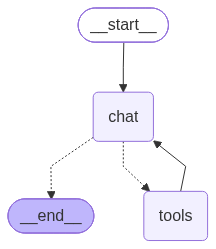

In [29]:
workflow= graph.compile()
workflow

In [11]:
reply=  workflow.invoke({'messages':[HumanMessage(content="Do you know the prime minister of bangladesh, answer by your own without searching")]})
reply['messages'][-1].content

'The current Prime Minister of Bangladesh is Sheikh Hasina.'

In [12]:
reply1=  workflow.invoke({'messages':[HumanMessage(content="Search online who is the current prime minister of bangladesh and show the result")]})
reply1['messages'][-1].content

'The current Prime Minister of Bangladesh is Tarique Rahman, also known as Tarique Zia. He has been serving since 2026.'

In [30]:
code="""
        def add(a: int, b: int)->int:            
        return a + b
        result = add(6, 7)
        print(result)
        """
reply2 = workflow.invoke({'messages':[HumanMessage(content=f"show me the output {code} using python_execution_tool")]})
reply2['messages'][-1].content


TypeError: PythonREPLTool._run() got an unexpected keyword argument 'result'

In [31]:
reply2

NameError: name 'reply2' is not defined

In [32]:
reply3=  workflow.invoke({'messages':[HumanMessage(content="Find me a video on LangGraph from youtube")]})
reply3['messages'][-1].content

TypeError: YouTubeSearchTool._run() got an unexpected keyword argument 'num_results'

In [34]:
reply4=  workflow.invoke({'messages':[HumanMessage(content="I need to contact support. Ask me for my account ID using human_tool.")]})
reply4['messages'][-1].content

''

In [17]:

reply5 = workflow.invoke({"messages": [HumanMessage(content="Calculate my age if I was born on 1999-12-20")]})
reply5["messages"][-1].content



'If you were born on 1999-12-20, you are 26 years, 9 months, and 3 days old.'

In [18]:

reply6 = workflow.invoke({"messages": [HumanMessage(content="What is the current weather in Chittagong?")]})
reply6["messages"][-1].content

'The current weather in Chittagong, Bangladesh is 28.9°C with a wind speed of 2.1 km/h and a weather code of 3.'